In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from torch.cuda.amp import autocast, GradScaler # hızlandırmak için 


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [33]:
cifar_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((28, 28)),
    transforms.RandomHorizontalFlip(), # Resimleri rastgele yatay çevirir
    transforms.RandomRotation(10),                
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))         
])

mnist_transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)# false olunca test seti indiriliyor

train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)

combined_train_dataset = ConcatDataset([train_cifar, train_mnist])

Files already downloaded and verified
Files already downloaded and verified


In [34]:
BATCH_SIZE = 128
lr = 0.001
patience = 3

In [35]:
train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

test_loader_cifar = DataLoader(test_cifar, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_mnist = DataLoader(test_mnist, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

**UnifiedCNN**, hem MNIST hem de CIFAR-10 verilerini işleyebilecek şekilde tasarlanmıştır.

**Mimarinin Temel Özellikleri:**
* **Giriş Katmanı:** Model, `1 kanal` (Grayscale) ve `28x28` boyutunda görüntüler alır. Bu standartlaştırma, farklı veri setlerini aynı ağa sokabilmemizi sağlar.
* **Öznitelik Çıkarımı (Backbone):** 3 adet ardışık Konvolüsyon Bloğu (Conv -> BatchNorm -> ReLU -> Pool) kullanılmıştır. Bu katmanlar, görüntünün "domain"ini (yani MNIST mi yoksa CIFAR mı olduğunu) ve içeriğini (hangi sınıf olduğunu) ayırt edecek görsel öznitelikleri öğrenir.
* **Bağlama Dayalı Sınıflandırma (Context-Dependent Classification):** En kritik kısım **Çıktı Katmanı (fc3)**'dır. Modelin sadece **10 adet çıktı nöronu** vardır.
    * Model, **0. Sınıf** çıktısını hem MNIST'teki "0 Rakamı" hem de CIFAR'daki "Uçak" için aktif etmeyi öğrenmelidir.
    * Bunu yapabilmesi için ağın, önceki katmanlarda görüntünün bağlamını (doku, karmaşıklık vb.) örtük olarak (implicitly) öğrenmesi gerekir.

In [36]:
class UnifiedCNN(nn.Module):
    def __init__(self, num_classes=10): # 10 sınıf var (cifar10)
        super(UnifiedCNN, self).__init__()
        
        #blok 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2) # Çıktı: 16x16
        self.dropout1 = nn.Dropout2d(p=0.25)

        #blok 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2) # Çıktı: 8x8
        self.dropout2 = nn.Dropout2d(p=0.25)

        #blok 3
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2) # Çıktı: 4x4
        self.dropout3 = nn.Dropout2d(p=0.25)

        # Fully Connected Layers
        self.flatten_dim = 256 * 3 * 3 #3x3 boyutunda 256 kanal var
        
        self.fc1 = nn.Linear(self.flatten_dim, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.dropout_fc1 = nn.Dropout(p=0.5)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)
        self.dropout_fc2 = nn.Dropout(p=0.5)
        
        # Çıktı katmanı: Sadece 10 sınıf var.
        # Model, girdinin domainine göre bu 10 sınıfı "yorumlamayı" öğrenmeli.
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        #blok 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)

        #blok 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)

        #blok 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.dropout3(x)

        # Flatten & Classifier
        x = x.view(-1, self.flatten_dim)
        
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc1(x)
        
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout_fc2(x)
        
        x = self.fc3(x)
        return x

In [37]:
model = UnifiedCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience)#, verbose=True

In [38]:
def evaluate(model, loader, dataset_name="Dataset"):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)
    print(f"   -> {dataset_name} Accuracy: {accuracy:.2f}% | Loss: {avg_loss:.4f}")
    return avg_loss, accuracy

**Eğitim Stratejisi:**
1.  **Karma Batch (Mixed Batches):** `train_loader`, MNIST ve CIFAR-10 verilerinin birleştirilmesiyle (`ConcatDataset`) oluşturulmuştur ve `shuffle=True` ile karıştırılmıştır.
    * Bu sayede model, bir iterasyonda el yazısı bir rakam görürken, hemen ardından doğal bir nesne (örn. araba) görebilir.
    * Bu durum, modelin "ezberlemesini" engeller ve her girdi için dinamik olarak bağlamı analiz etmeye zorlar.

2.  **Ayrı Değerlendirme (Domain-Specific Evaluation):**
    * Model eğitilirken veriler karışıktır, ancak başarıyı ölçmek için `evaluate` fonksiyonu MNIST ve CIFAR-10 test setleri üzerinde **ayrı ayrı** çalıştırılır.
    * Bu, projenin başarı kriterini ölçer: Model aynı anda her iki alanda da (Domain A ve Domain B) yüksek başarım gösterebiliyor mu?

3.  **Optimizasyon:** `Adam` optimizasyonu ve `ReduceLROnPlateau` kullanılarak, loss (hata) değeri düştükçe öğrenme hızı (learning rate) ayarlanır ve modelin daha hassas yakınsaması sağlanır.

In [ ]:
def train(epochs=15):
    print(f"\nEğitim Başlıyor... Hedef Epoch: {epochs}")
    print("-" * 60)

    scaler = GradScaler() # Hızlandırıcı
    history = {
        'train_loss': [],
        'train_acc': [],
        'mnist_loss': [],
        'mnist_acc': [],
        'cifar_loss': [],
        'cifar_acc': []
    }
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            loop.set_postfix(loss=loss.item())
            
        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        
        #Her epoch sonunda domain bazlı performansları ayrı ayrı ölçüyoruz
        #Model ikisini de öğreniyor mu?
        val_loss_mnist, val_acc_mnist = evaluate(model, test_loader_mnist, "MNIST Test")
        val_loss_cifar, val_acc_cifar = evaluate(model, test_loader_cifar, "CIFAR Test")

        history['mnist_loss'].append(val_loss_mnist)
        history['mnist_acc'].append(val_acc_mnist)
        history['cifar_loss'].append(val_loss_cifar)
        history['cifar_acc'].append(val_acc_cifar)
        
        # Scheduler adım (Ortalama loss'a göre learning rate düşür)
        avg_val_loss = (val_loss_mnist + val_loss_cifar) / 2
        scheduler.step(avg_val_loss)
        print("-" * 60)

    return history

In [40]:
history = train(epochs=5)


Eğitim Başlıyor... Hedef Epoch: 5
------------------------------------------------------------


Epoch 1: Train Loss: 0.8611 | Train Acc: 69.30%
   -> MNIST Test Accuracy: 98.89% | Loss: 0.0346
   -> CIFAR Test Accuracy: 56.98% | Loss: 1.2269
------------------------------------------------------------


Epoch 2: Train Loss: 0.6126 | Train Acc: 78.88%
   -> MNIST Test Accuracy: 99.00% | Loss: 0.0319
   -> CIFAR Test Accuracy: 63.15% | Loss: 1.0382
------------------------------------------------------------


Epoch 3: Train Loss: 0.5350 | Train Acc: 81.54%
   -> MNIST Test Accuracy: 99.40% | Loss: 0.0195
   -> CIFAR Test Accuracy: 68.18% | Loss: 0.9158
------------------------------------------------------------


Epoch 4: Train Loss: 0.4844 | Train Acc: 83.44%
   -> MNIST Test Accuracy: 99.29% | Loss: 0.0225
   -> CIFAR Test Accuracy: 70.62% | Loss: 0.8451
------------------------------------------------------------


Epoch 5: Train Loss: 0.4496 | Train Acc: 84.58%
   -> MNIST Test Accuracy: 99.39% | Loss: 0.0219
   -> CIFAR Test Accuracy: 72.20% | Loss: 0.8069
------------------------------------------------------------


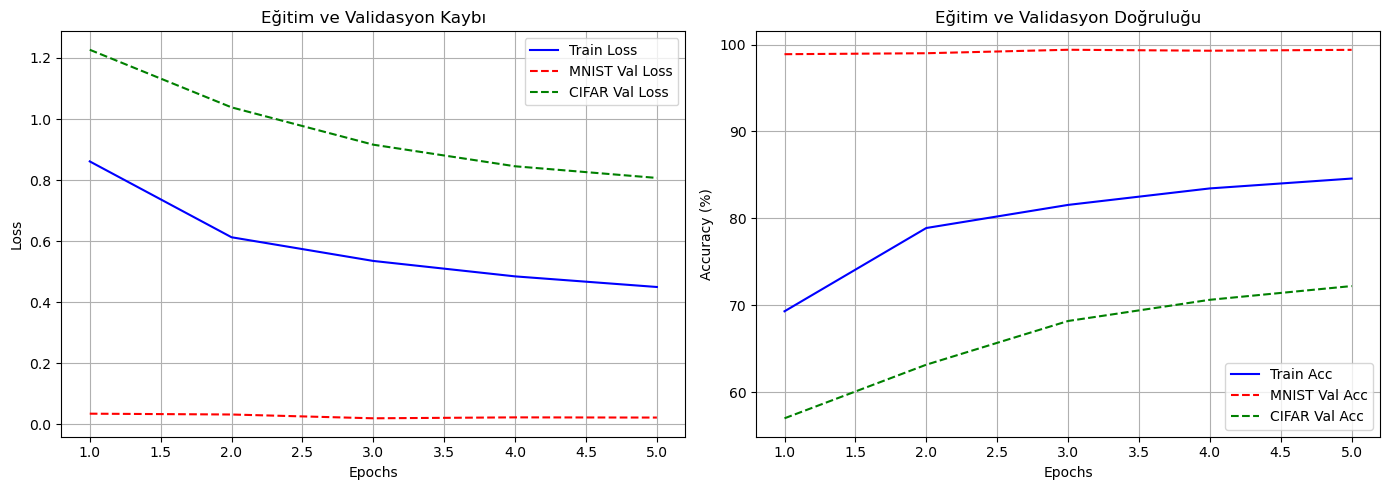

In [41]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Grafik: Loss (Kayıp)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['mnist_loss'], 'r--', label='MNIST Val Loss')
    plt.plot(epochs, history['cifar_loss'], 'g--', label='CIFAR Val Loss')
    plt.title('Eğitim ve Validasyon Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 2. Grafik: Accuracy (Doğruluk)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['mnist_acc'], 'r--', label='MNIST Val Acc')
    plt.plot(epochs, history['cifar_acc'], 'g--', label='CIFAR Val Acc')
    plt.title('Eğitim ve Validasyon Doğruluğu')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Grafikleri çiz
plot_history(history)

MNIST Confusion Matrix Çiziliyor...


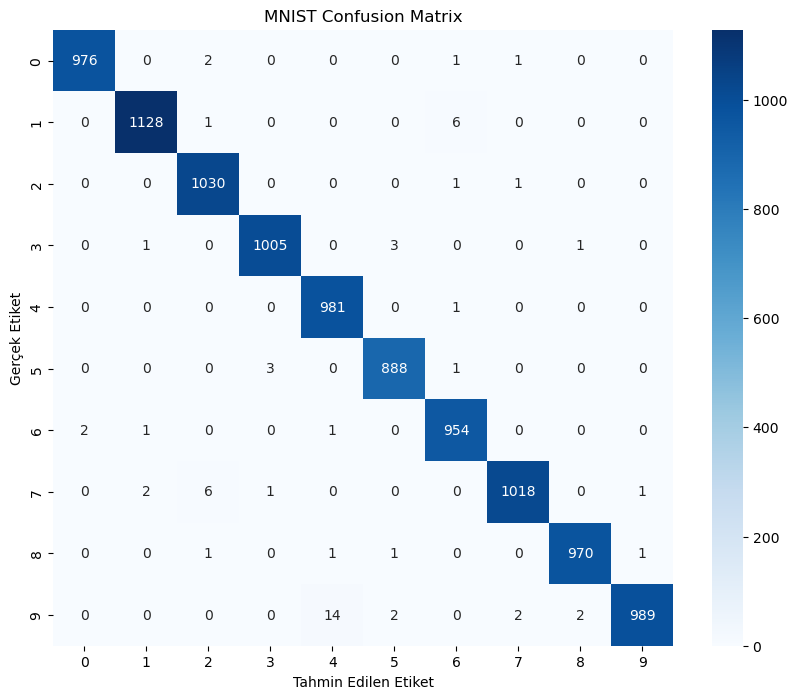

CIFAR-10 Confusion Matrix Çiziliyor...


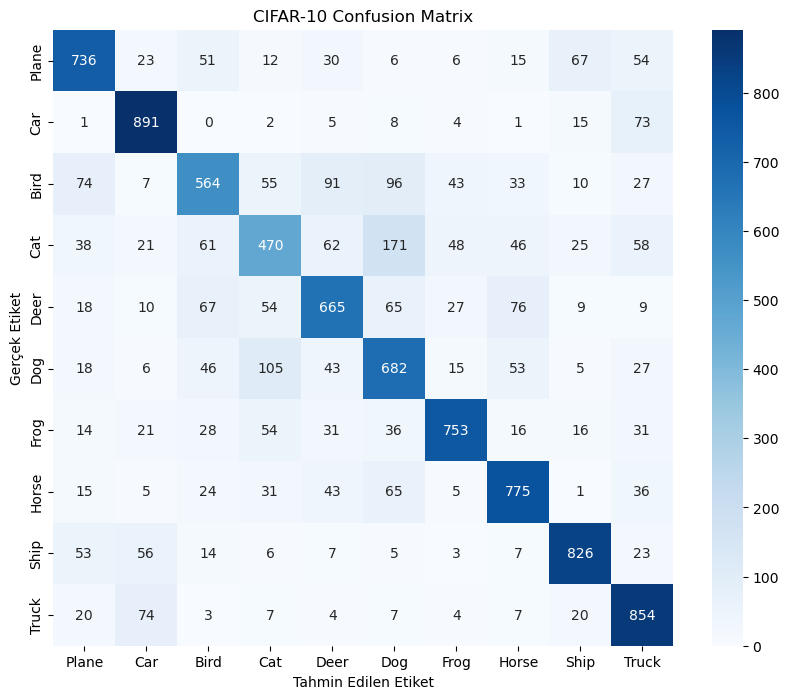

In [42]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(model, loader, classes, title="Confusion Matrix"):
    y_true, y_pred = get_predictions(model, loader)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.show()

# Sınıf isimleri
cifar_classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
mnist_classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# MNIST için Confusion Matrix
print("MNIST Confusion Matrix Çiziliyor...")
plot_confusion_matrix(model, test_loader_mnist, mnist_classes, title="MNIST Confusion Matrix")

# CIFAR-10 için Confusion Matrix
print("CIFAR-10 Confusion Matrix Çiziliyor...")
plot_confusion_matrix(model, test_loader_cifar, cifar_classes, title="CIFAR-10 Confusion Matrix")